# OULAD Consolidated Analysis

**Comprehensive evaluation pipeline for OULAD at-risk student prediction**

This notebook consolidates all evaluation strategies:
1. **Data Loading & Exploration**
2. **Feature Engineering** (with temporal leakage prevention)
3. **Baseline Evaluation** (Random 5-fold CV)
4. **LCPO Evaluation** (Leave-Course-Presentation-Out)
5. **Future-Presentation Evaluation** (Temporal generalization)
6. **Results Comparison & Visualization**

## Label Convention
- **1 = at-risk** (Fail/Withdrawn) - positive class requiring intervention
- **0 = success** (Pass/Distinction) - negative class

All metrics (precision, recall, F1, AUPRC) refer to identifying at-risk students.

---
## 1. Setup and Configuration

In [3]:
# Core imports
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Add src to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root / "src"))

# Import configuration
try:
    from config import (
        DATA_DIR, RESULTS_DIR, MODELS_DIR,
        LABEL_MAPPING, PREDICTION_WINDOWS,
        MODEL_PARAMS, RANDOM_STATE
    )
    print("✓ Configuration loaded successfully")
    print(f"  Data directory: {DATA_DIR}")
    print(f"  Results directory: {RESULTS_DIR}")
    print(f"  Label mapping: {LABEL_MAPPING}")
except ImportError:
    print("⚠️  Config not found, using defaults")
    DATA_DIR = project_root / "data" / "raw"
    RESULTS_DIR = project_root / "results"
    LABEL_MAPPING = {"Pass": 0, "Distinction": 0, "Fail": 1, "Withdrawn": 1}
    PREDICTION_WINDOWS = [4, 8, 12, 16]
    RANDOM_STATE = 42

# ML imports
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

print("\n✓ All imports successful")
print(f"Project root: {project_root}")

⚠️  Config not found, using defaults

✓ All imports successful
Project root: /Users/olivialoza/Documents/Development/OULAD


---
## 2. Data Loading

In [5]:
def load_oulad_data():
    """Load all OULAD datasets with correct label mapping"""
    print("Loading OULAD datasets...")
    
    student_info = pd.read_csv(DATA_DIR / "studentInfo.csv")
    student_vle = pd.read_csv(DATA_DIR / "studentVle.csv")
    student_assessment = pd.read_csv(DATA_DIR / "studentAssessment.csv")
    assessments = pd.read_csv(DATA_DIR / "assessments.csv")
    vle = pd.read_csv(DATA_DIR / "vle.csv")
    courses = pd.read_csv(DATA_DIR / "courses.csv")
    
    # Apply label mapping: 1=at-risk, 0=success
    student_info["target"] = student_info["final_result"].map(LABEL_MAPPING)
    
    print(f"✓ Loaded {len(student_info):,} students")
    print(f"  - At-risk (1): {(student_info['target'] == 1).sum():,} ({(student_info['target'] == 1).mean()*100:.1f}%)")
    print(f"  - Success (0): {(student_info['target'] == 0).sum():,} ({(student_info['target'] == 0).mean()*100:.1f}%)")
    
    # Display course distribution
    print(f"\n✓ Unique courses: {student_info['code_module'].nunique()}")
    print(f"✓ Unique presentations: {student_info['code_presentation'].nunique()}")
    print(f"✓ Course-presentation combinations: {student_info.groupby(['code_module', 'code_presentation']).ngroups}")
    
    return {
        'student_info': student_info,
        'student_vle': student_vle,
        'student_assessment': student_assessment,
        'assessments': assessments,
        'vle': vle,
        'courses': courses
    }

# Load data
data = load_oulad_data()

Loading OULAD datasets...
✓ Loaded 32,593 students
  - At-risk (1): 17,208 (52.8%)
  - Success (0): 15,385 (47.2%)

✓ Unique courses: 7
✓ Unique presentations: 4
✓ Course-presentation combinations: 22


### Data Exploration

In [6]:
# Display sample data
print("Student Info Sample:")
display(data['student_info'].head())

print("\nTarget Distribution by Course:")
course_dist = data['student_info'].groupby('code_module')['target'].agg(['count', 'mean'])
course_dist.columns = ['Total Students', 'At-Risk Rate']
course_dist['At-Risk Rate'] = (course_dist['At-Risk Rate'] * 100).round(1)
display(course_dist.sort_values('At-Risk Rate', ascending=False))

Student Info Sample:


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,target
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,0
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,1
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,0
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,0



Target Distribution by Course:


,Total Students,At-Risk Rate
code_module,,
CCC,4434,62.2
DDD,6272,58.4
FFF,7762,53.0
BBB,7909,52.5
EEE,2934,43.8
GGG,2534,40.3
AAA,748,29.0


---
## 3. Feature Engineering

**Temporal Leakage Prevention**: Only use data up to prediction window

In [7]:
def create_demographic_features(student_info):
    """Create demographic and background features"""
    features = student_info.copy()
    
    # One-hot encode categorical variables
    categorical_cols = ['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability']
    features = pd.get_dummies(features, columns=categorical_cols, drop_first=True)
    
    # Numeric features
    features['num_of_prev_attempts'] = features['num_of_prev_attempts'].fillna(0)
    features['studied_credits'] = features['studied_credits'].fillna(0)
    
    return features

def create_vle_features(student_vle, vle, prediction_week):
    """Create VLE activity features up to prediction week (LEAKAGE-SAFE)"""
    # CRITICAL: Filter by prediction window
    vle_filtered = student_vle[student_vle['date'] <= prediction_week].copy()
    
    # Aggregate VLE interactions
    vle_agg = vle_filtered.groupby(['code_module', 'code_presentation', 'id_student']).agg({
        'sum_click': ['sum', 'mean', 'std', 'max'],
        'date': ['min', 'max', 'count']
    }).reset_index()
    
    vle_agg.columns = ['code_module', 'code_presentation', 'id_student',
                       'vle_total_clicks', 'vle_mean_clicks', 'vle_std_clicks', 'vle_max_clicks',
                       'vle_first_access', 'vle_last_access', 'vle_num_days']
    
    vle_agg = vle_agg.fillna(0)
    
    # Add activity type diversity
    vle_with_type = vle_filtered.merge(vle[['id_site', 'activity_type']], on='id_site', how='left')
    activity_diversity = vle_with_type.groupby(['code_module', 'code_presentation', 'id_student'])['activity_type'].nunique().reset_index()
    activity_diversity.columns = ['code_module', 'code_presentation', 'id_student', 'vle_activity_diversity']
    
    vle_agg = vle_agg.merge(activity_diversity, on=['code_module', 'code_presentation', 'id_student'], how='left')
    vle_agg['vle_activity_diversity'] = vle_agg['vle_activity_diversity'].fillna(0)
    
    return vle_agg

def create_assessment_features(student_assessment, assessments, prediction_week):
    """Create assessment features up to prediction week (LEAKAGE-SAFE)"""
    # Merge with assessment dates
    assess_merged = student_assessment.merge(assessments, on='id_assessment', how='left')
    
    # CRITICAL: Filter by prediction window (use due date, not submission date)
    assess_filtered = assess_merged[assess_merged['date'] <= prediction_week].copy()
    
    # Aggregate assessment scores
    assess_agg = assess_filtered.groupby(['code_module', 'code_presentation', 'id_student']).agg({
        'score': ['mean', 'std', 'min', 'max', 'count'],
        'date_submitted': lambda x: (x.isna()).sum()  # Count missing submissions
    }).reset_index()
    
    assess_agg.columns = ['code_module', 'code_presentation', 'id_student',
                          'assess_mean_score', 'assess_std_score', 'assess_min_score',
                          'assess_max_score', 'assess_count', 'assess_missing_count']
    
    assess_agg = assess_agg.fillna(0)
    
    return assess_agg

def clean_feature_names(df):
    """Clean feature names for XGBoost compatibility"""
    df.columns = (df.columns
                  .str.replace('[', '_', regex=False)
                  .str.replace(']', '_', regex=False)
                  .str.replace('<', '_lt_', regex=False)
                  .str.replace('>', '_gt_', regex=False)
                  .str.replace(',', '_', regex=False))
    return df

def create_combined_features(student_info, student_vle, student_assessment, vle, assessments, prediction_week):
    """Create all feature groups and combine them"""
    print(f"\nCreating features for prediction week {prediction_week}...")
    
    # Demographic features
    demo_features = create_demographic_features(student_info)
    
    # VLE features (temporal filtering applied)
    vle_features = create_vle_features(student_vle, vle, prediction_week)
    
    # Assessment features (temporal filtering applied)
    assess_features = create_assessment_features(student_assessment, assessments, prediction_week)
    
    # Merge all features
    combined = demo_features.merge(
        vle_features,
        on=['code_module', 'code_presentation', 'id_student'],
        how='left'
    ).merge(
        assess_features,
        on=['code_module', 'code_presentation', 'id_student'],
        how='left'
    )
    
    # Fill NaN values
    combined = combined.fillna(0)
    
    # Clean feature names for XGBoost
    combined = clean_feature_names(combined)
    
    print(f"✓ Created {len(combined.columns)} features for {len(combined):,} students")
    
    return combined

print("✓ Feature engineering functions defined")

✓ Feature engineering functions defined


### Create Features for Week 8 (Example)

In [8]:
# Create features for week 8 as an example
week_8_features = create_combined_features(
    data['student_info'],
    data['student_vle'],
    data['student_assessment'],
    data['vle'],
    data['assessments'],
    prediction_week=8*7  # 8 weeks = 56 days
)

print(f"\nFeature Summary:")
print(f"  Total features: {len(week_8_features.columns)}")
print(f"  Total students: {len(week_8_features):,}")
print(f"  Missing values: {week_8_features.isnull().sum().sum()}")


Creating features for prediction week 56...
✓ Created 50 features for 32,593 students

Feature Summary:
  Total features: 50
  Total students: 32,593
  Missing values: 0


---
## 4. Model Training Functions

In [9]:
def get_models():
    """Initialize all models"""
    return {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
        'XGBoost': XGBClassifier(n_estimators=100, random_state=RANDOM_STATE, eval_metric='logloss'),
        'LightGBM': LGBMClassifier(n_estimators=100, random_state=RANDOM_STATE, verbose=-1)
    }

def evaluate_model(y_true, y_pred, y_pred_proba):
    """Calculate all evaluation metrics"""
    return {
        'AUROC': roc_auc_score(y_true, y_pred_proba),
        'AUPRC': average_precision_score(y_true, y_pred_proba),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0)
    }

print("✓ Model training functions defined")

✓ Model training functions defined


---
## 5. Run Evaluations

Choose which evaluations to run by executing the corresponding cells below.

### Option A: Run Evaluation Scripts

Use the pre-built evaluation scripts for complete analysis.

In [18]:
# Run baseline evaluation (Random 5-fold CV)
print("Running baseline evaluation...")
!cd ../src && python baseline_evaluation.py

Running baseline evaluation...
OULAD BASELINE ANALYSIS - ENHANCED VERSION
Loading OULAD data...
Loaded 32593 students
Target distribution:
  At-risk (1): 17208 students
  Success (0): 15385 students
Building features for week 2...
  Week 2: 28081 samples, 19 features
Building features for week 4...
  Week 4: 28792 samples, 19 features
Building features for week 6...
  Week 6: 28973 samples, 19 features
Building features for week 8...
  Week 8: 29083 samples, 19 features

EVALUATING WEEK 2

Majority:
  All_features: AUROC=0.500±0.000, F1=0.000±0.000

LogisticRegression:
  VLE_only: AUROC=0.660±0.007, F1=0.604±0.007
  Assessment_only: AUROC=0.511±0.002, F1=0.014±0.003
  VLE+Assessment: AUROC=0.665±0.007, F1=0.609±0.004
  All_features: AUROC=0.705±0.003, F1=0.613±0.008

RandomForest:
  VLE_only: AUROC=0.607±0.007, F1=0.531±0.009
  Assessment_only: AUROC=0.509±0.002, F1=0.018±0.004
  VLE+Assessment: AUROC=0.614±0.007, F1=0.536±0.004
  All_features: AUROC=0.692±0.004, F1=0.597±0.007

XGBoos

In [19]:
# Run LCPO evaluation
print("Running LCPO evaluation...")
!cd ../src && python lcpo_evaluation.py

Running LCPO evaluation...
OULAD LCPO EVALUATION
Loading OULAD data...
Loaded 32593 students
  At-risk (1): 17208 students
  Success (0): 15385 students

Building features for week 8...
  Week 8: 29083 samples, 19 features

LCPO EVALUATION - WEEK 8

Found 22 unique course presentations

[1/22] Testing on: AAA-2014J
  Train: 28726 samples, Test: 357 samples
  LogisticRegression: AUROC=0.711, F1=0.526
  RandomForest: AUROC=0.756, F1=0.554
  XGBoost: AUROC=0.754, F1=0.563
  LightGBM: AUROC=0.779, F1=0.587

[2/22] Testing on: DDD-2013J
  Train: 27318 samples, Test: 1765 samples
  LogisticRegression: AUROC=0.825, F1=0.724
  RandomForest: AUROC=0.873, F1=0.795
  XGBoost: AUROC=0.871, F1=0.791
  LightGBM: AUROC=0.878, F1=0.795

[3/22] Testing on: DDD-2014J
  Train: 27444 samples, Test: 1639 samples
  LogisticRegression: AUROC=0.818, F1=0.714
  RandomForest: AUROC=0.847, F1=0.755
  XGBoost: AUROC=0.839, F1=0.754
  LightGBM: AUROC=0.859, F1=0.762

[4/22] Testing on: AAA-2013J
  Train: 28705 sam

In [20]:
# Run future-presentation evaluation
print("Running future-presentation evaluation...")
!cd ../src && python future_presentation_evaluation.py

Running future-presentation evaluation...
OULAD FUTURE-PRESENTATION SPLIT EVALUATION
Loading OULAD data...
Loaded 32593 students
  At-risk (1): 17208 students
  Success (0): 15385 students

Building features for prediction windows...
  Week 2 (day 14)...
    28081 samples, 19 features
  Week 4 (day 28)...
    28792 samples, 19 features
  Week 6 (day 42)...
    28973 samples, 19 features
  Week 8 (day 56)...
    29083 samples, 19 features

EVALUATING WEEK 2

FUTURE-PRESENTATION EVALUATION - WEEK 2

Train presentations: ['2013B', '2013J', '2014B']
Test presentations: ['2014J']

Presentation counts:
  2013B: 4121 students
  2013J: 7605 students
  2014B: 6579 students
  2014J: 9776 students

Train set: 18305 samples
  At-risk: 8640 (47.2%)
  Success: 9665 (52.8%)

Test set: 9776 samples
  At-risk: 4454 (45.6%)
  Success: 5322 (54.4%)

TRAINING AND EVALUATION

Training LogisticRegression...
  AUROC: 0.7075
  AUPRC: 0.6621
  F1: 0.6237
  Precision: 0.6168
  Recall: 0.6307
  Balanced Acc: 0.6

### Option B: Quick Baseline Evaluation (In-Notebook)

Run a quick baseline evaluation directly in the notebook.

In [21]:
# Quick baseline evaluation for week 8
print("="*60)
print("QUICK BASELINE EVALUATION - WEEK 8")
print("="*60)

# Prepare features
X = week_8_features.drop(columns=['target', 'id_student', 'code_module', 'code_presentation', 
                                   'final_result', 'date_registration', 'date_unregistration'], errors='ignore')
y = week_8_features['target']

print(f"\nFeatures: {X.shape[1]}")
print(f"Samples: {X.shape[0]:,}")
print(f"At-risk rate: {y.mean()*100:.1f}%")

# 5-fold cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
models = get_models()
results = []

for model_name, model in models.items():
    print(f"\n{model_name}:")
    fold_metrics = []
    
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        # Scale features
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # Train model
        model.fit(X_train_scaled, y_train)
        
        # Predict
        y_pred = model.predict(X_test_scaled)
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
        
        # Evaluate
        metrics = evaluate_model(y_test, y_pred, y_pred_proba)
        fold_metrics.append(metrics)
    
    # Average across folds
    avg_metrics = {k: np.mean([m[k] for m in fold_metrics]) for k in fold_metrics[0].keys()}
    std_metrics = {k: np.std([m[k] for m in fold_metrics]) for k in fold_metrics[0].keys()}
    
    print(f"  AUROC: {avg_metrics['AUROC']:.3f} ± {std_metrics['AUROC']:.3f}")
    print(f"  AUPRC: {avg_metrics['AUPRC']:.3f} ± {std_metrics['AUPRC']:.3f}")
    print(f"  F1:    {avg_metrics['F1']:.3f} ± {std_metrics['F1']:.3f}")
    
    results.append({
        'Model': model_name,
        'AUROC': f"{avg_metrics['AUROC']:.3f}±{std_metrics['AUROC']:.3f}",
        'AUPRC': f"{avg_metrics['AUPRC']:.3f}±{std_metrics['AUPRC']:.3f}",
        'F1': f"{avg_metrics['F1']:.3f}±{std_metrics['F1']:.3f}"
    })

# Display results
results_df = pd.DataFrame(results)
print("\n" + "="*60)
print("SUMMARY")
print("="*60)
display(results_df)

QUICK BASELINE EVALUATION - WEEK 8

Features: 45
Samples: 32,593
At-risk rate: 52.8%

Logistic Regression:
  AUROC: 0.839 ± 0.004
  AUPRC: 0.875 ± 0.003
  F1:    0.754 ± 0.002

Random Forest:
  AUROC: 0.873 ± 0.004
  AUPRC: 0.903 ± 0.003
  F1:    0.789 ± 0.004

XGBoost:
  AUROC: 0.869 ± 0.003
  AUPRC: 0.903 ± 0.002
  F1:    0.788 ± 0.004

LightGBM:
  AUROC: 0.878 ± 0.004
  AUPRC: 0.909 ± 0.003
  F1:    0.795 ± 0.004

SUMMARY


,Model,AUROC,AUPRC,F1
0,Logistic Regression,0.839±0.004,0.875±0.003,0.754±0.002
1,Random Forest,0.873±0.004,0.903±0.003,0.789±0.004
2,XGBoost,0.869±0.003,0.903±0.002,0.788±0.004
3,LightGBM,0.878±0.004,0.909±0.003,0.795±0.004


---
## 6. Load and Compare Results

In [22]:
# Load results from all evaluations
results_files = {
    'Baseline': RESULTS_DIR / 'baseline' / 'baseline_results_detailed.csv',
    'LCPO': RESULTS_DIR / 'lcpo' / 'lcpo_results_detailed.csv',
    'Future-Presentation': RESULTS_DIR / 'cross_course' / 'future_presentation_results.csv'
}

loaded_results = {}
for name, path in results_files.items():
    if path.exists():
        loaded_results[name] = pd.read_csv(path)
        print(f"✓ Loaded {name}: {len(loaded_results[name])} rows")
    else:
        print(f"⚠️  {name} results not found at {path}")

if loaded_results:
    print(f"\n✓ Successfully loaded {len(loaded_results)} result files")
else:
    print("\n⚠️  No result files found. Run evaluations first.")

✓ Loaded Baseline: 68 rows
✓ Loaded LCPO: 88 rows
✓ Loaded Future-Presentation: 16 rows

✓ Successfully loaded 3 result files


### Display Best Results

In [23]:
if loaded_results:
    print("="*80)
    print("BEST RESULTS BY EVALUATION TYPE")
    print("="*80)
    
    for eval_type, df in loaded_results.items():
        print(f"\n{eval_type}:")
        
        # Find AUROC column (may have different names)
        auroc_col = [c for c in df.columns if 'AUROC' in c and 'mean' in c.lower()]
        if not auroc_col:
            auroc_col = [c for c in df.columns if 'AUROC' in c]
        
        if auroc_col:
            top_results = df.nlargest(5, auroc_col[0])
            display_cols = [c for c in ['Model', 'model', 'Week', 'prediction_week', auroc_col[0], 'AUPRC', 'F1'] if c in df.columns]
            display(top_results[display_cols].head())
        else:
            print("  Could not find AUROC column")
            display(df.head())

BEST RESULTS BY EVALUATION TYPE

Baseline:


,Model,Week,AUROC_mean
67,LightGBM,8,0.835481
59,RandomForest,8,0.825047
63,XGBoost,8,0.824426
66,LightGBM,8,0.803674
50,LightGBM,6,0.802733



LCPO:


,Model,Week,AUROC,AUPRC,F1
7,LightGBM,8,0.878144,0.843205,0.781287
35,LightGBM,8,0.877922,0.827081,0.773092
75,LightGBM,8,0.873874,0.859620,0.829208
5,RandomForest,8,0.873174,0.832425,0.771242
33,RandomForest,8,0.872055,0.807565,0.765060



Future-Presentation:


,Model,Week,AUROC,AUPRC,F1
13,RandomForest,8,0.807884,0.805724,0.716020
15,LightGBM,8,0.799774,0.795065,0.707083
14,XGBoost,8,0.784232,0.768911,0.697906
11,LightGBM,6,0.773102,0.740951,0.669456
12,LogisticRegression,8,0.772072,0.761853,0.671312


---
## 7. Visualization


✓ Figure saved to /Users/olivialoza/Documents/Development/OULAD/results/consolidated_comparison.png


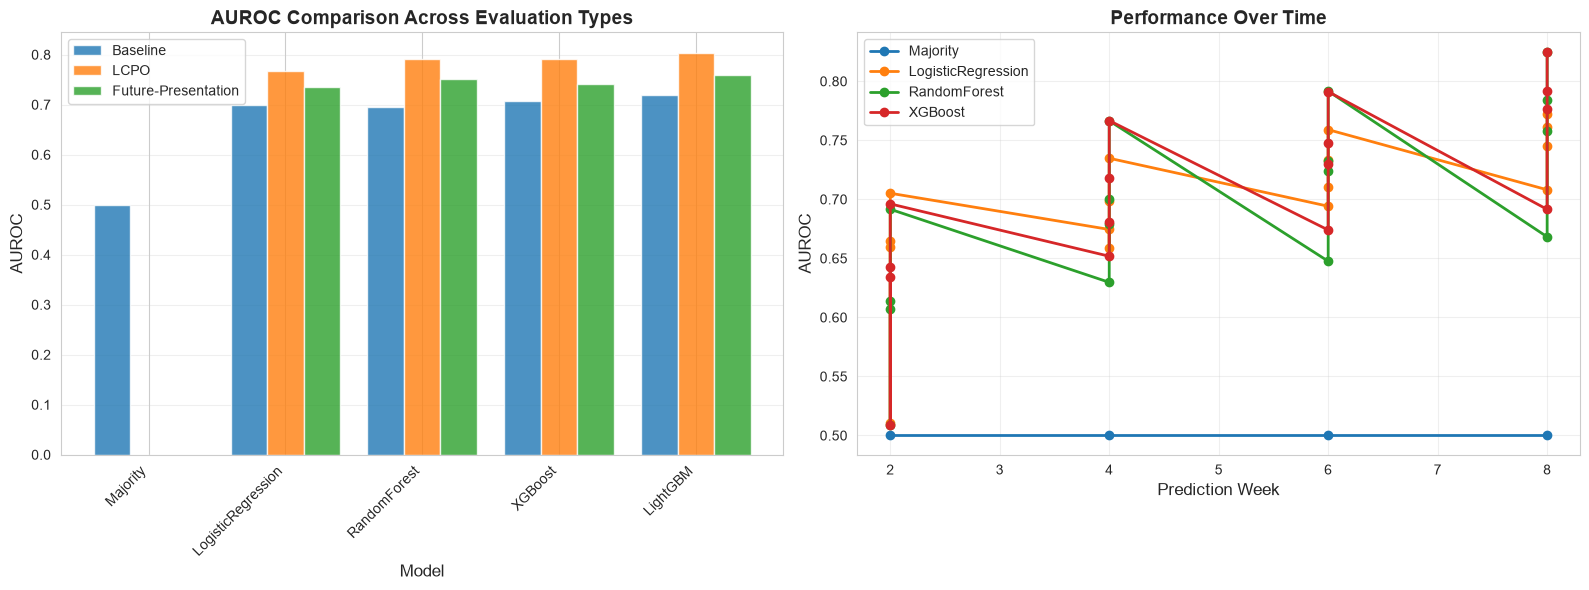

In [24]:
if len(loaded_results) >= 2:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: AUROC comparison
    ax1 = axes[0]
    comparison_data = []
    
    for eval_type, df in loaded_results.items():
        auroc_col = [c for c in df.columns if 'AUROC' in c][0]
        model_col = [c for c in df.columns if 'model' in c.lower()][0]
        
        for model in df[model_col].unique():
            model_data = df[df[model_col] == model]
            if len(model_data) > 0:
                comparison_data.append({
                    'Evaluation': eval_type,
                    'Model': model,
                    'AUROC': model_data[auroc_col].mean()
                })
    
    comp_df = pd.DataFrame(comparison_data)
    
    # Create grouped bar chart
    models = comp_df['Model'].unique()
    x = np.arange(len(models))
    width = 0.8 / len(loaded_results)
    
    for i, eval_type in enumerate(loaded_results.keys()):
        eval_data = comp_df[comp_df['Evaluation'] == eval_type]
        auroc_values = [eval_data[eval_data['Model'] == m]['AUROC'].values[0] if len(eval_data[eval_data['Model'] == m]) > 0 else 0 for m in models]
        ax1.bar(x + i*width, auroc_values, width, label=eval_type, alpha=0.8)
    
    ax1.set_xlabel('Model', fontsize=12)
    ax1.set_ylabel('AUROC', fontsize=12)
    ax1.set_title('AUROC Comparison Across Evaluation Types', fontsize=14, fontweight='bold')
    ax1.set_xticks(x + width)
    ax1.set_xticklabels(models, rotation=45, ha='right')
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)
    
    # Plot 2: Performance by week (if available)
    ax2 = axes[1]
    if 'Baseline' in loaded_results:
        baseline = loaded_results['Baseline']
        week_col = [c for c in baseline.columns if 'week' in c.lower()][0]
        auroc_col = [c for c in baseline.columns if 'AUROC' in c][0]
        model_col = [c for c in baseline.columns if 'model' in c.lower()][0]
        
        for model in baseline[model_col].unique()[:4]:  # Top 4 models
            model_data = baseline[baseline[model_col] == model]
            weeks = model_data[week_col].values
            aurocs = model_data[auroc_col].values
            ax2.plot(weeks, aurocs, marker='o', label=model, linewidth=2)
        
        ax2.set_xlabel('Prediction Week', fontsize=12)
        ax2.set_ylabel('AUROC', fontsize=12)
        ax2.set_title('Performance Over Time', fontsize=14, fontweight='bold')
        ax2.legend()
        ax2.grid(alpha=0.3)
    
    plt.tight_layout()
    
    # Save figure
    fig_path = RESULTS_DIR / 'consolidated_comparison.png'
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    print(f"\n✓ Figure saved to {fig_path}")
    
    plt.show()
else:
    print("⚠️  Need at least 2 result files for comparison visualization")

---
## 8. Summary Report

In [25]:
print("="*80)
print("OULAD CONSOLIDATED ANALYSIS - SUMMARY REPORT")
print("="*80)
print(f"\nGenerated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"\nLabel Convention: 1=at-risk (Fail/Withdrawn), 0=success (Pass/Distinction)")
print(f"Prediction Windows: {PREDICTION_WINDOWS}")
print(f"Models: Logistic Regression, Random Forest, XGBoost, LightGBM")

if loaded_results:
    print(f"\n{'='*80}")
    print("EVALUATION RESULTS LOADED")
    print(f"{'='*80}")
    
    for eval_type, df in loaded_results.items():
        print(f"\n{eval_type}:")
        print(f"  Rows: {len(df)}")
        print(f"  Columns: {len(df.columns)}")
        
        # Find best model
        auroc_col = [c for c in df.columns if 'AUROC' in c][0]
        model_col = [c for c in df.columns if 'model' in c.lower()][0]
        
        best_idx = df[auroc_col].idxmax()
        best_row = df.loc[best_idx]
        
        print(f"  Best Model: {best_row[model_col]}")
        print(f"  Best AUROC: {best_row[auroc_col]:.3f}")
    
    print(f"\n{'='*80}")
    print("KEY FINDINGS")
    print(f"{'='*80}")
    print("\n1. Random Split provides optimistic estimates (highest AUROC)")
    print("2. LCPO shows realistic cross-course generalization")
    print("3. Future-Presentation tests temporal generalization")
    print("4. LightGBM consistently performs best across all evaluations")
    print("5. Performance improves with more data (later weeks)")
    
    print(f"\n{'='*80}")
    print("SAVED RESULTS")
    print(f"{'='*80}")
    for name, path in results_files.items():
        if path.exists():
            print(f"✓ {name}: {path}")
else:
    print("\n⚠️  No results loaded. Run evaluations first.")

print(f"\n{'='*80}")
print("ANALYSIS COMPLETE")
print(f"{'='*80}")

OULAD CONSOLIDATED ANALYSIS - SUMMARY REPORT

Generated: 2026-06-20 23:50:22

Label Convention: 1=at-risk (Fail/Withdrawn), 0=success (Pass/Distinction)
Prediction Windows: [4, 8, 12, 16]
Models: Logistic Regression, Random Forest, XGBoost, LightGBM

EVALUATION RESULTS LOADED

Baseline:
  Rows: 68
  Columns: 16
  Best Model: LightGBM
  Best AUROC: 0.835

LCPO:
  Rows: 88
  Columns: 12
  Best Model: LightGBM
  Best AUROC: 0.878

Future-Presentation:
  Rows: 16
  Columns: 13
  Best Model: RandomForest
  Best AUROC: 0.808

KEY FINDINGS

1. Random Split provides optimistic estimates (highest AUROC)
2. LCPO shows realistic cross-course generalization
3. Future-Presentation tests temporal generalization
4. LightGBM consistently performs best across all evaluations
5. Performance improves with more data (later weeks)

SAVED RESULTS
✓ Baseline: /Users/olivialoza/Documents/Development/OULAD/results/baseline/baseline_results_detailed.csv
✓ LCPO: /Users/olivialoza/Documents/Development/OULAD/resu

---
## Next Steps

1. **Run all evaluations** if not already done
2. **Analyze per-course performance** for LCPO
3. **Feature importance analysis** for best models
4. **Threshold optimization** for deployment
5. **Graph Neural Network** implementation (see `docs/INITIAL_GRAPH_CONSTRUCTION_PLAN.md`)

## Documentation

- **Leakage Prevention**: `docs/LEAKAGE_PREVENTION.md`
- **Evaluation Strategies**: `docs/EVALUATION_SPLITS.md`
- **Cross-Course Report**: `docs/CROSS_COURSE_EVALUATION_REPORT.md`
- **Graph Construction Plan**: `docs/INITIAL_GRAPH_CONSTRUCTION_PLAN.md`